## 6CS012 - Artificial Intelligence and Machine Learning.
## Practical Aspects of Training CNN for Image Classification
##Student Name: Atul Adhikari
## Student ID: 2408982
## Worksheet 6

### 1.1 - Dataset Setup

## Unzipping the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/Copy of FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# path to the train folder
train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/FruitinAmazon/train'

# get class names from subdirectories
class_names = sorted(os.listdir(train_dir))
if not class_names:
    print("No class directories found in the train dataset folder.")
else:
    print('Classes found:', class_names)
    print('Total classes:', len(class_names))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total classes: 6


### 1.2 - Check for Corrupted Images

In [5]:
from genericpath import isdir
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for each_image in images:
            image_path = os.path.join(class_path, each_image)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(image_path)

if corrupted_images:
    print(f"Total Corrupted images : {len(corrupted_images)}")
    for each_corrupted_images in corrupted_images:
        print(f"Corrupted: {each_corrupted_images}")
else:
    print("No corrupted images found!")

No corrupted images found!


### 1.3 - Check Class Balance

In [26]:
class_counts = {}

for class_name in class_names:
    folder_path = os.path.join(train_dir, class_name)
    if os.path.isdir(folder_path):
        images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("Checking class Imbalance\n")
for key,value in class_counts.items():
    print(f"Class: {key}, Count: {value}")


Checking class Imbalance

Class: acai, Count: 15
Class: cupuacu, Count: 15
Class: graviola, Count: 15
Class: guarana, Count: 15
Class: pupunha, Count: 15
Class: tucuma, Count: 15


### 1.4 Visualize Sample Images from Each Class

Total selected images: 6


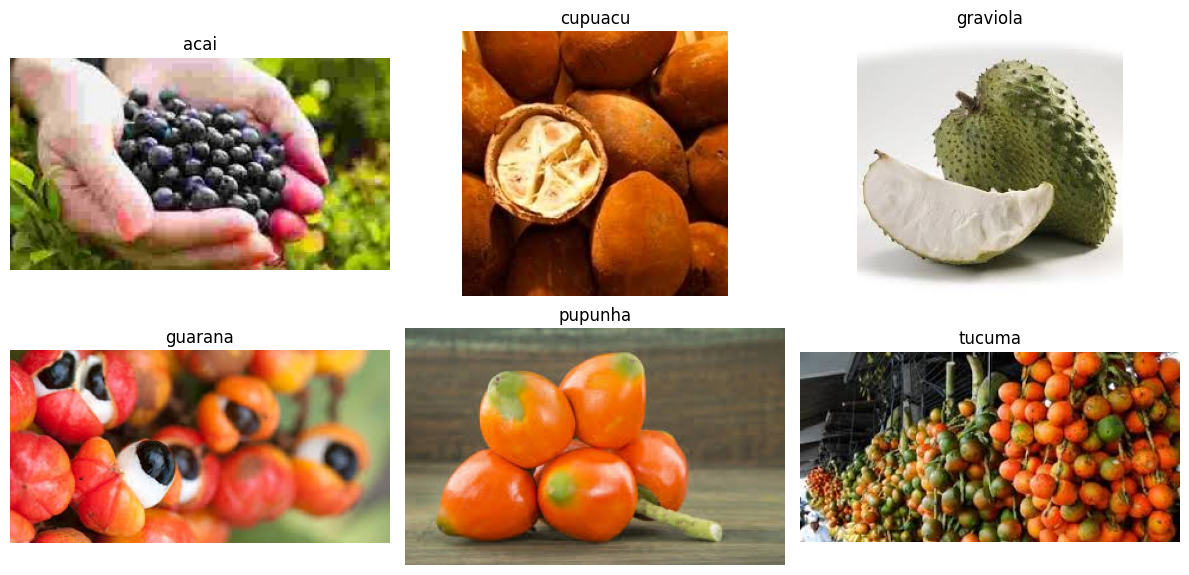

In [32]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_folder = os.path.join(train_dir, class_name)
    if os.path.isdir(class_folder):
        imgs = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if imgs:
            chosen = os.path.join(class_folder, random.choice(imgs))
            selected_images.append(chosen)
            selected_labels.append(class_name)

num_classes = len(selected_images)
print(f"Total selected images: {num_classes}")
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

## Task 2:
Data Loading, Augmentation and Preprocessing

--> This is where things change from last week. Instead of just rescaling, we now add data augmentation layers directly into the preprocessing pipeline. Augmentation only fires during training so the validation and test sets are not affected.

In [40]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

img_height = 128
img_width  = 128
batch_size = 16
validation_split = 0.2

# load train and val splits from the train directory
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset='both',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("Training and validation datasets loaded!\n")

for image, label in train_ds.take(1):
    print(f"Images shape: {image.shape}")
    print(f"Label shape: {label.shape}")


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Training and validation datasets loaded!

Images shape: (16, 128, 128, 3)
Label shape: (16,)


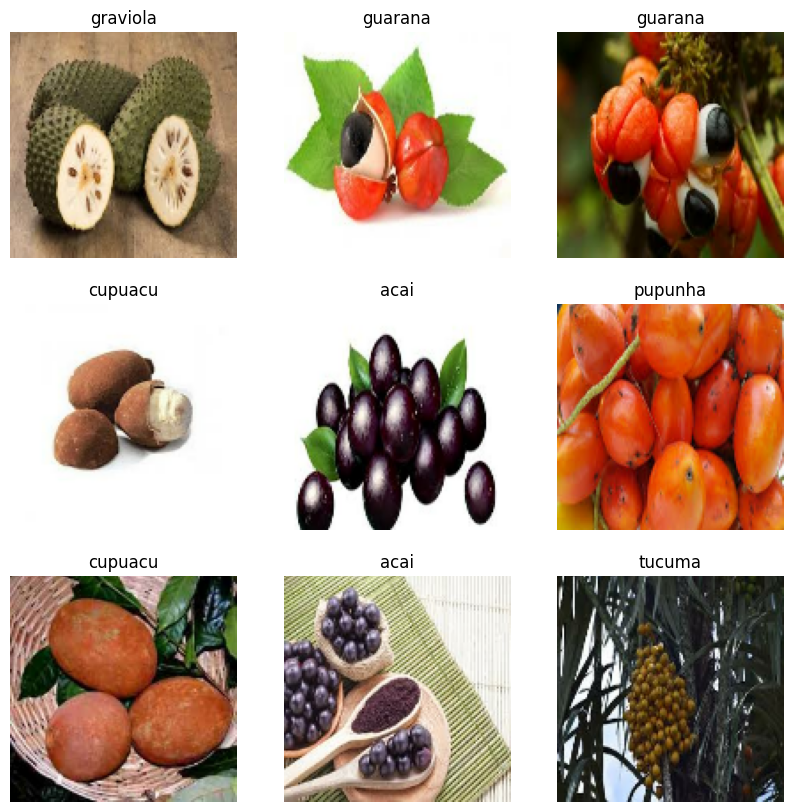

In [45]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [46]:
# load the separate test directory
test_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/FruitinAmazon/test'

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

print("Test dataset loaded!")

Found 30 files belonging to 6 classes.
Test dataset loaded!


In [47]:
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


### 2.1 Define Data Augmentation Layers
Using the newer tf.keras.layers API here. These get baked into the model so augmentation runs on GPU during fit() and is automatically skipped at eval time.

In [52]:
# define the augmentation layers we want
data_augmentation_layers = [
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

### 2.2 Visualize Augmented Images
Just checking that the augmentations actually look reasonable before plugging them into the model.

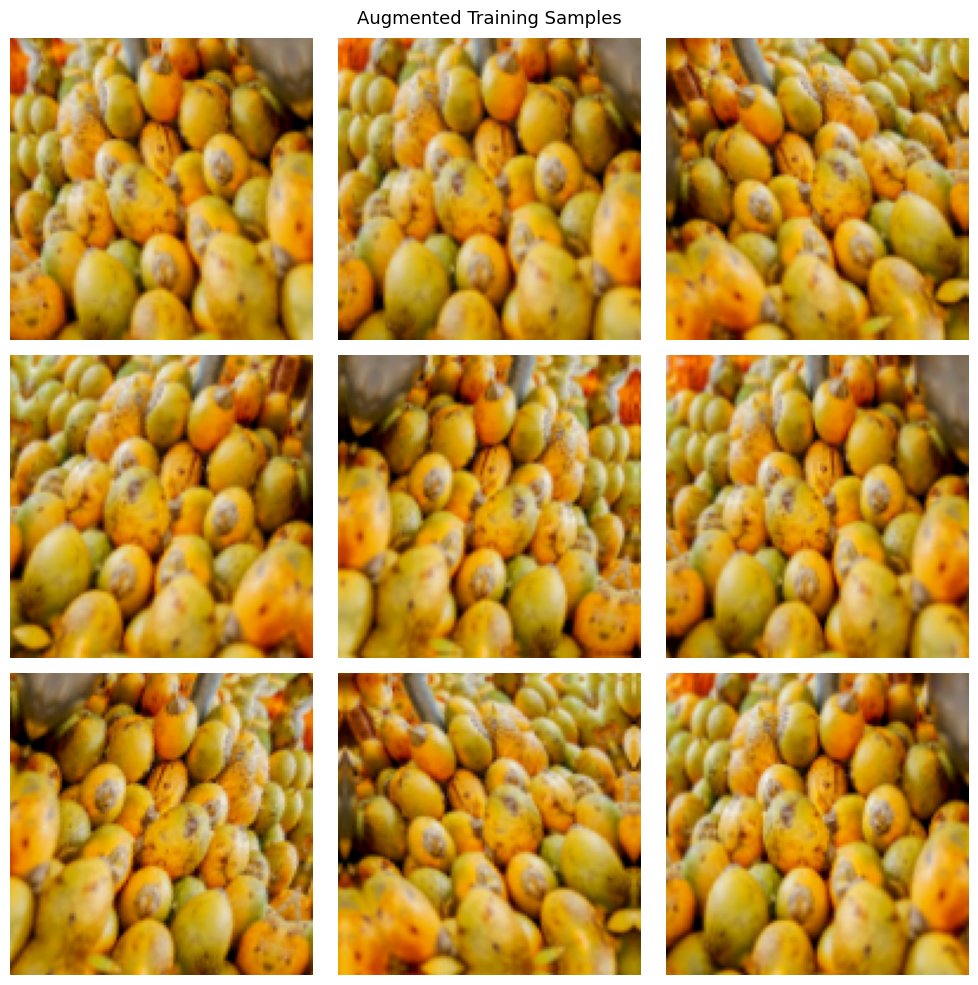

In [56]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype('uint8'))
        plt.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.show()

## Task 3: Build the Improved CNN Model
The model from last week only had two conv blocks with no regularisation. This time we go deeper with four conv blocks  and add BatchNorm after each conv layer along with Dropout to keep overfitting in check. Rescaling is also moved inside the model so it benefits from GPU acceleration alongside the augmentation.

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, Activation)

input_shape = (img_height, img_width, 3)

model = Sequential([
    # augmentation + rescaling at the front
    layers.Lambda(data_augmentation, input_shape=input_shape),
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # # Block 3
    # Conv2D(128, (3, 3), padding='same'),
    # BatchNormalization(),
    # Activation('relu'),
    # MaxPooling2D((2, 2)),
    # Dropout(0.25),

    # # Block 4
    # Conv2D(256, (3, 3), padding='same'),
    # BatchNormalization(),
    # Activation('relu'),
    # MaxPooling2D((2, 2)),
    # Dropout(0.25),

    Flatten(),

    # Dense layers
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Dense(256),
    # BatchNormalization(),
    # Activation('relu'),
    # Dropout(0.5),

    # Dense(128),
    # BatchNormalization(),
    # Activation('relu'),
    # Dropout(0.5),

    # output
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,409,798 (32.08 MB)

 Trainable params: 8,409,350 (32.08 MB)

 Non-trainable params: 448 (1.75 KB)

##Checking if class labels are mismatched

In [72]:
print(train_ds.class_names)
print(val_ds.class_names)
print(test_ds.class_names)

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## Task 4: Compile and Train the Model

In [77]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [78]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_model_ws6.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3663 - loss: 1.9183
Epoch 1: val_accuracy improved from None to 0.27778, saving model to best_model_ws6.h5



Epoch 1: finished saving model to best_model_ws6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4306 - loss: 1.7320 - val_accuracy: 0.2778 - val_loss: 2.1795 - learning_rate: 0.0010
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.5104 - loss: 1.2975
Epoch 2: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 743ms/step - accuracy: 0.5417 - loss: 1.2114 - val_accuracy: 0.1667 - val_loss: 1.9252 - learning_rate: 0.0010
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.5750 - loss: 1.1205
Epoch 3: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 686ms/step - accuracy: 0.5833 - loss: 1.1093 - val_accuracy: 0.2778 - val_loss: 2.0580 - learning_rate: 0.0010
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.7184 - loss: 0.8230
Epoch 4: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 986ms/step - accuracy: 0.7222 - loss: 0.8951 - val_accuracy: 0.1667 - val_loss: 2.1853 - learnin

### Training and Validation Curves

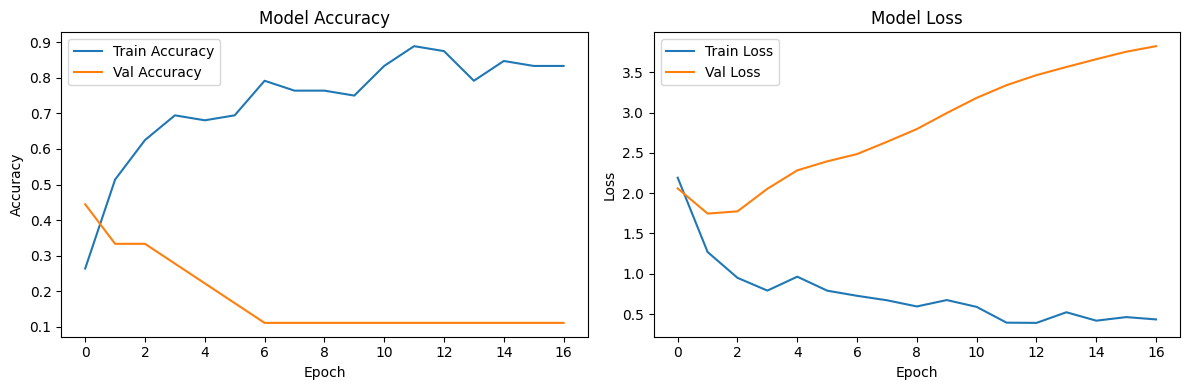

In [75]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [79]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.2000 - loss: 1.7445
Test Loss     : 1.7445
Test Accuracy : 0.2000


## Task 6: Save and Load the Model

In [80]:
model.save('cnn_fruit_classifier_ws6.h5')
print("Model saved as cnn_fruit_classifier_ws6.h5")

Model saved as cnn_fruit_classifier_ws6.h5


In [81]:
from tensorflow.keras.models import load_model

loaded_model = load_model('cnn_fruit_classifier_ws6.h5')
print("Model loaded successfully!")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f}")

Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.2000 - loss: 1.7445
Loaded Model Test Loss     : 1.7445
Loaded Model Test Accuracy : 0.2000


## Task 7: Predictions and Classification Report

In [82]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [83]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.15      0.40      0.22         5
    graviola       0.27      0.80      0.40         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.20        30
   macro avg       0.07      0.20      0.10        30
weighted avg       0.07      0.20      0.10        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


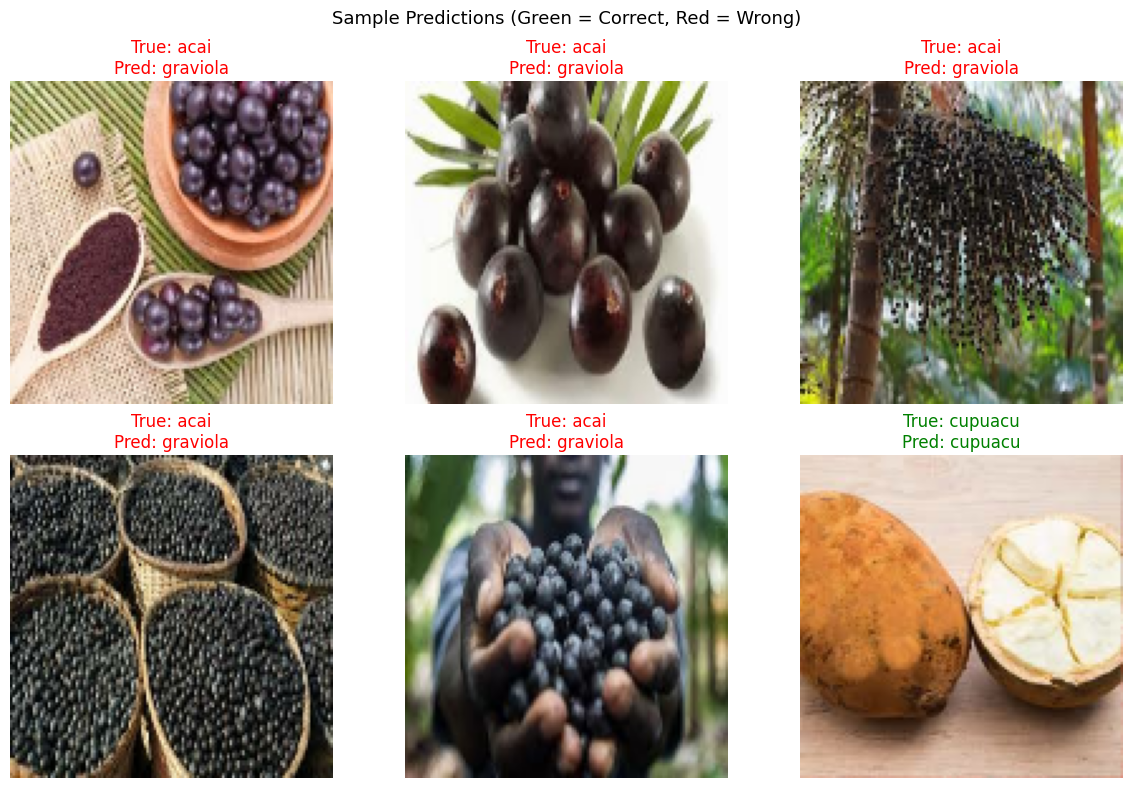

In [84]:
sample_images = []
sample_labels = []

for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

preds = loaded_model.predict(sample_images[:6])
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(sample_images[i].astype('uint8'))
    true_name = class_names[sample_labels[i]]
    pred_name = class_names[pred_labels[i]]
    color = 'green' if true_name == pred_name else 'red'
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

## Task 2 (Worksheet 6): Transfer Learning with VGG16
Now we try a completely different approach using a model that was already trained on ImageNet. The idea is to freeze all the VGG16 layers and only train a small classifier on top. This way we are borrowing the feature extraction knowledge from a much larger training run and just adapting it to our 6-class fruit problem.

### Step 1 Reload Dataset at 224×224
VGG16 expects 224×224 RGB images, so we need to reload the datasets at that size.

In [85]:
# VGG16 needs 224x224 input
vgg_img_size = (224, 224)
vgg_batch_size = 16

train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=123,
    image_size=vgg_img_size,
    batch_size=vgg_batch_size
)

test_ds_vgg = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=vgg_img_size,
    batch_size=vgg_batch_size,
    shuffle=False,
    seed=123
)

print("Datasets reloaded for VGG16 (224x224)")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Datasets reloaded for VGG16 (224x224)


### Step 2 Load the Pre-trained VGG16 Base
We load VGG16 without the top classification layers (include_top=False) and with the ImageNet weights. The base model layers are then frozen so they don't get updated during training.

In [87]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# load without the top dense layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# freeze all base model layers as we only want to train our own head
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 loaded {len(base_model.layers)} layers, all frozen")
base_model.summary()

VGG16 loaded 19 layers, all frozen


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 3 Add a Custom Classification Head

In [88]:
# rescaling layer to bring pixel values to [0, 1]
inputs = keras.Input(shape=(224, 224, 3))
x = layers.Rescaling(1./255)(inputs)

# pass through the frozen VGG16 base
x = base_model(x, training=False)

# reduce the spatial dimensions down to a single vector per image
x = GlobalAveragePooling2D()(x)

# a couple of dense layers before the final output
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# output layer of 6 fruit classes
outputs = Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=inputs, outputs=outputs)
vgg_model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,214 (57.64 MB)

 Trainable params: 395,526 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 4 Compile and Train the Transfer Learning Model

In [89]:
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_checkpoint = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

vgg_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

vgg_history = vgg_model.fit(
    train_ds_vgg,
    epochs=50,
    validation_data=val_ds_vgg,
    callbacks=[vgg_checkpoint, vgg_early_stop]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.1184 - loss: 2.0749 
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_vgg16_model.h5



Epoch 1: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 56s 11s/step - accuracy: 0.0972 - loss: 2.0642 - val_accuracy: 0.1111 - val_loss: 1.8099
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.1479 - loss: 1.8165
Epoch 2: val_accuracy did not improve from 0.11111
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 13s/step - accuracy: 0.1250 - loss: 1.8802 - val_accuracy: 0.1111 - val_loss: 1.8129
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.1413 - loss: 2.0525
Epoch 3: val_accuracy did not improve from 0.11111
5/5 ━━━━━━━━━━━━━━━━━━━━ 61s 13s/step - accuracy: 0.1806 - loss: 1.9526 - val_accuracy: 0.1111 - val_loss: 1.8183
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1660 - loss: 1.8835
Epoch 4: val_accuracy did not improve from 0.11111
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 10s/step - accuracy: 0.1528 - loss: 1.8245 - val_accuracy: 0.0556 - val_loss: 1.8253
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.1406 - loss: 1.9455
Epoch 5: val


Epoch 5: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 13s/step - accuracy: 0.1250 - loss: 1.8760 - val_accuracy: 0.1667 - val_loss: 1.8246
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2972 - loss: 1.7567
Epoch 6: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 10s/step - accuracy: 0.3194 - loss: 1.7635 - val_accuracy: 0.1667 - val_loss: 1.8234
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1535 - loss: 1.9376
Epoch 7: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - accuracy: 0.1528 - loss: 1.9353 - val_accuracy: 0.1667 - val_loss: 1.8185
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2174 - loss: 1.8195
Epoch 8: val_accuracy improved from 0.16667 to 0.27778, saving model to best_vgg16_model.h5



Epoch 8: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 10s/step - accuracy: 0.1806 - loss: 1.8235 - val_accuracy: 0.2778 - val_loss: 1.8101
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3090 - loss: 1.7292
Epoch 9: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 51s 10s/step - accuracy: 0.2639 - loss: 1.7784 - val_accuracy: 0.2222 - val_loss: 1.8055
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2045 - loss: 1.7833
Epoch 10: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 80s 10s/step - accuracy: 0.1944 - loss: 1.7935 - val_accuracy: 0.1667 - val_loss: 1.7986
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2427 - loss: 1.7634
Epoch 11: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 10s/step - accuracy: 0.2083 - loss: 1.7821 - val_accuracy: 0.2222 - val_loss: 1.7899
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2660 - loss: 1.7416
Epoch 1


Epoch 25: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.4167 - loss: 1.5473 - val_accuracy: 0.3889 - val_loss: 1.6637
Epoch 26/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4413 - loss: 1.5126
Epoch 26: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - accuracy: 0.4306 - loss: 1.5129 - val_accuracy: 0.3889 - val_loss: 1.6551
Epoch 27/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3378 - loss: 1.5875
Epoch 27: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 60s 13s/step - accuracy: 0.3611 - loss: 1.5557 - val_accuracy: 0.3889 - val_loss: 1.6405
Epoch 28/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4531 - loss: 1.4450
Epoch 28: val_accuracy improved from 0.38889 to 0.44444, saving model to best_vgg16_model.h5



Epoch 28: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 10s/step - accuracy: 0.4583 - loss: 1.4616 - val_accuracy: 0.4444 - val_loss: 1.6255
Epoch 29/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3750 - loss: 1.6009
Epoch 29: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 59s 12s/step - accuracy: 0.4167 - loss: 1.5366 - val_accuracy: 0.4444 - val_loss: 1.6161
Epoch 30/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4476 - loss: 1.5619
Epoch 30: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.4722 - loss: 1.5143 - val_accuracy: 0.4444 - val_loss: 1.6086
Epoch 31/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4875 - loss: 1.4856
Epoch 31: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 13s/step - accuracy: 0.5000 - loss: 1.4443 - val_accuracy: 0.4444 - val_loss: 1.6009
Epoch 32/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4323 - loss: 1.4576
Epoc


Epoch 34: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 92s 13s/step - accuracy: 0.5417 - loss: 1.4306 - val_accuracy: 0.5000 - val_loss: 1.5799
Epoch 35/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3924 - loss: 1.4760
Epoch 35: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 13s/step - accuracy: 0.4306 - loss: 1.4363 - val_accuracy: 0.4444 - val_loss: 1.5773
Epoch 36/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4389 - loss: 1.4363
Epoch 36: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 73s 10s/step - accuracy: 0.4861 - loss: 1.4245 - val_accuracy: 0.4444 - val_loss: 1.5718
Epoch 37/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5521 - loss: 1.4043
Epoch 37: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 80s 10s/step - accuracy: 0.4583 - loss: 1.4334 - val_accuracy: 0.4444 - val_loss: 1.5687
Epoch 38/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5517 - loss: 1.3045
Epoc

### Training Curves VGG16 Transfer Learning

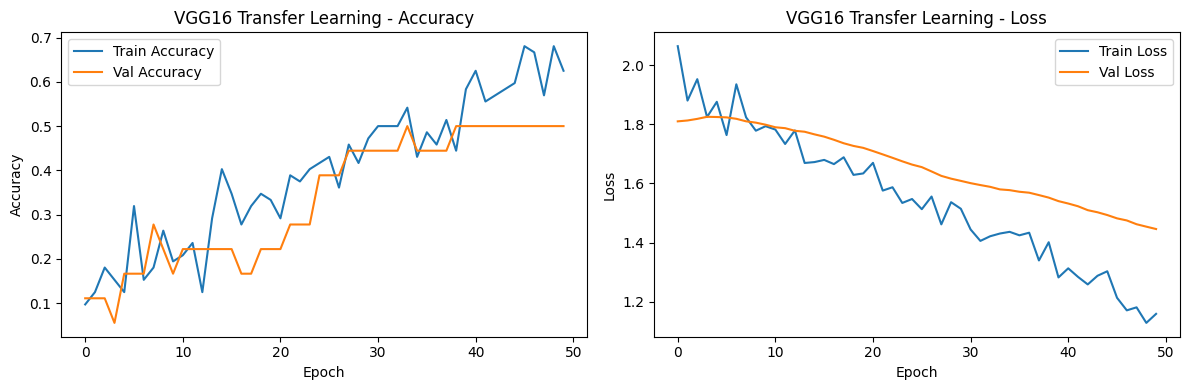

In [90]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Transfer Learning - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16 Transfer Learning - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Step 5 - Evaluate the VGG16 Model

In [91]:
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 Test Loss     : {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy : {vgg_test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step - accuracy: 0.5000 - loss: 1.4618
VGG16 Test Loss     : 1.4618
VGG16 Test Accuracy : 0.5000


### Step 6 - Classification Report and Inference Output

In [92]:
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)
    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(predicted_labels)

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print("VGG16 Classification Report:")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

VGG16 Classification Report:
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.40      0.40      0.40         5
    graviola       0.75      0.60      0.67         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.30      0.60      0.40         5

    accuracy                           0.50        30
   macro avg       0.47      0.50      0.48        30
weighted avg       0.47      0.50      0.48        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


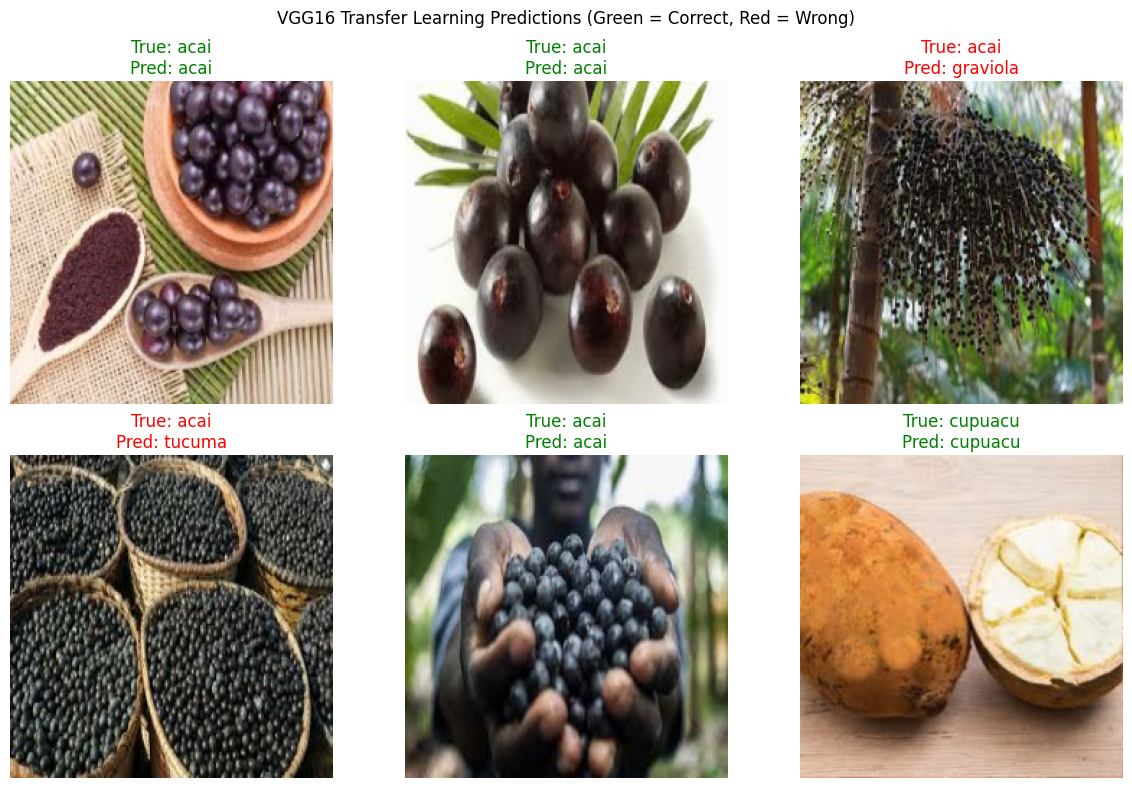

In [93]:
# visual inference check same as before
vgg_sample_images = []
vgg_sample_labels = []

for images, labels in test_ds_vgg.take(1):
    vgg_sample_images = images.numpy()
    vgg_sample_labels = labels.numpy()

vgg_preds = vgg_model.predict(vgg_sample_images[:6])
vgg_pred_labels = np.argmax(vgg_preds, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(vgg_sample_images[i].astype('uint8'))
    true_name = class_names[vgg_sample_labels[i]]
    pred_name = class_names[vgg_pred_labels[i]]
    color = 'green' if true_name == pred_name else 'red'
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color=color)
    axes[i].axis('off')

plt.suptitle('VGG16 Transfer Learning Predictions (Green = Correct, Red = Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

### Comparison: Scratch CNN vs VGG16 Transfer Learning

In [96]:
print("Model Performance Comparison")
print(f"{'Model':<30}{'Test Accuracy':>12}")
print(f"{'Custom CNN (from scratch)':<30}{test_acc:>11.4f}")
print(f"{'VGG16 (transfer learning)':<30}{vgg_test_acc:>11.4f}")

if vgg_test_acc > test_acc:
    diff = (vgg_test_acc - test_acc) * 100
    print(f"\nVGG16 outperformed the custom CNN by {diff:.2f} percentage points.")
    print("Transfer learning clearly helped here — the ImageNet features generalise well.")
else:
    diff = (test_acc - vgg_test_acc) * 100
    print(f"\nCustom CNN actually performed {diff:.2f} percentage points better.")
    print("This can happen with small datasets where fine-tuning the head alone isn't enough.")

Model Performance Comparison
Model                         Test Accuracy
Custom CNN (from scratch)          0.2000
VGG16 (transfer learning)          0.5000

VGG16 outperformed the custom CNN by 30.00 percentage points.
Transfer learning clearly helped here — the ImageNet features generalise well.
